# 06: Link Prediction — Full Pipeline (Final)

**מטרה:** בניית מודל ML מלא לחיזוי שיתופי פעולה עתידיים בין שחקנים, לפי העיצוב המדויק של התרגיל (Temporal Split עם Train עד 2020 ו-Test על 2021-2025), **עם `years_ahead` כפיצ'ר אמיתי במודל** כדי לבדוק אמפירית איזה אופק חיזוי (1-5 שנים) הכי מדויק.

## עיצוב זמני (Temporal Design) — לפי הספציפיקציית המדויקת + years_ahead:

| | **Graph (X features)** | **Target (Y labels)** |
|---|---|---|
| **Train** | `G_1990_2015` (1990-2015) | קשרים חדשים שנוצרו בתוך 1-5 שנים אחרי 2015 (2016-2020), עם `years_ahead` כפיצ'ר |
| **Test** | `G_1990_2020` (1990-2020, "הגרף המלא עד 2020") | קשרים חדשים שנוצרו בפועל בתוך 1-5 שנים אחרי 2020 (2021-2025), עם `years_ahead` כפיצ'ר |

- פיצ'רים ($X$) מחושבים **רק** מהגרף הקיים בנקודת החיתוך (ללא מידע מהעתיד — מניעת Data Leakage)
- **`years_ahead` (1,2,3,4,5) הוא פיצ'ר אמיתי** — כל זוג מופיע עם כמה שורות (אחת לכל אופק שבו הוא positive/negative), כדי שהמודל ילמד את התלות בזמן ונוכל לבדוק איזה אופק הכי מדויק
- קשרים שכבר קיימים בבסיס מוסרים לחלוטין — מנבאים **רק קשרים חדשים**

## תהליך:
1. בניית הגרפים: `G_1990_2015`, `G_1990_2020`, `G_1990_2025` (לצורך Train/Test) + `G_full_2025` (הגרף המלא ההיסטורי, לשלב החיזוי העתידי בלבד)
2. בניית כל הפיצ'רים: Topological (5) + Centrality (16) + Temporal (10) + Genre/Director (7) + **SVD Embeddings/Matrix Factorization (2)** + **years_ahead (1)** = 41 פיצ'רים
3. בניית Train Set (בסיס=2015 → יעדים 1-5 שנים → 2016-2020) ו-Test Set (בסיס=2020 → יעדים 1-5 שנים → 2021-2025)
4. אימון Random Forest, הערכה על test set + Feature Selection
5. ניתוח שגיאות: False Positives, False Negatives, True Positives + **ניתוח ביצועים לפי אופק חיזוי** (years_ahead=1..5) — איזה אופק הכי מדויק
6. חיזוי עתידי (ספקולטיבי) על הגרף המלא (1918-2025) עם האופק הטוב ביותר שנמצא

**תוצאה:** מודל Random Forest שמוערך על holdout אמיתי (2021-2025) עם Precision, Recall, F1, AUC-ROC, ובחירת אופק החיזוי האופטימלי.

In [6]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Local imports
sys.path.append('../src')
from graph_build import load_cast_edges, build_full_graph
from link_prediction import (
    build_graph_for_years,
    get_new_pairs, sample_negatives,
    build_link_dataset, compute_centralities,
    train_random_forest, evaluate_model
)
from link_features import build_feature_matrix, svd_node_embeddings

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All imports successful")

✅ All imports successful


## שלב 1: טעינת נתונים וגרפים

In [11]:
# Load data
cast_df = load_cast_edges('../data/processed/cast_edges.csv')
movies_df = pd.read_csv('../data/processed/movies.csv') if Path('../data/processed/movies.csv').exists() \
    else cast_df[['movie_slug','movie_title','year','genre','directors']].drop_duplicates('movie_slug')

# Temporal design (exact spec):
# - Train:  X features from G_1990_2015 (graph up to 2015). Y_train = new pairs that connect
#           in G_1990_2020 (i.e. new links formed 2016-2020) but were NOT connected in G_1990_2015.
# - Test:   X features from G_1990_2020 ("graph up to 2020", matches the assignment's
#           "model based on the graph from period 1990-2020"). Y_test = new pairs that connect
#           in G_1990_2025 (i.e. new links ACTUALLY formed 2021-2025) but were NOT connected in
#           G_1990_2020 — this is the true holdout, evaluated with real ground truth.
# G_full_2025 is a SEPARATE, TRUE full graph (from the earliest films, 1918, through 2025) used
# ONLY for the final speculative future-prediction step (2026+, no ground truth) — using the
# whole historical network (not restricted to 1990+) so features reflect every actor ever.
G_1990_2015 = build_graph_for_years(cast_df, year_min=1990, year_max=2015)
G_1990_2020 = build_graph_for_years(cast_df, year_min=1990, year_max=2020)
G_1990_2025 = build_graph_for_years(cast_df, year_min=1990, year_max=2025)
G_full_2025 = build_graph_for_years(cast_df, year_min=1918, year_max=2025)

print(f"📊 G_1990_2015 (train features): {G_1990_2015.number_of_nodes()} nodes, {G_1990_2015.number_of_edges()} edges")
print(f"📊 G_1990_2020 (test features):  {G_1990_2020.number_of_nodes()} nodes, {G_1990_2020.number_of_edges()} edges")
print(f"📊 G_1990_2025 (test target, holdout ground truth): {G_1990_2025.number_of_nodes()} nodes, {G_1990_2025.number_of_edges()} edges")

print(f"📊 G_full_2025 (1918-2025, full history): {G_full_2025.number_of_nodes()} nodes, {G_full_2025.number_of_edges()} edges")
print(f"📊 cast_df columns: {cast_df.columns.tolist()}")

📊 G_1990_2015 (train features): 691 nodes, 1907 edges
📊 G_1990_2020 (test features):  837 nodes, 2653 edges
📊 G_1990_2025 (test target, holdout ground truth): 1080 nodes, 4601 edges
📊 G_full_2025 (1918-2025, full history): 1365 nodes, 5947 edges
📊 cast_df columns: ['movie_slug', 'movie_title', 'year', 'genre', 'directors', 'cast_source', 'billing_position', 'actor_name', 'actor_slug', 'period']


## שלב 2: בניית כל הפיצ'רים (41 פיצ'רים) — כולל years_ahead

### פיצ'רים:
- **Topological (5):** Common Neighbors, Jaccard, Adamic-Adar, Preferential Attachment, Shortest Path
- **Centrality (16):** Degree, Betweenness, Closeness, Eigenvector (u/v/product/diff לכל אחד)
- **Temporal (10):** career_length, career_overlap, film_count, is_alive ועוד (מניעת Data Leakage)
- **Genre/Director (7):** genre_diversity, genre_overlap, director_count, director_overlap ועוד
- **SVD Embeddings / Matrix Factorization (2):** `svd_cosine_sim`, `svd_dot_product` — TruncatedSVD על מטריצת השכנות המשוקללת
- **years_ahead (1):** אופק החיזוי בשנים (1,2,3,4,5) — פיצ'ר אמיתי, לא רק פרמטר קונספטואלי. מאפשר למודל ללמוד את התלות בזמן ולבדוק אמפירית איזה אופק הכי מדויק


## שלב 3: יצירת Train/Test Sets רב-אופקיים (Multi-Horizon) עם years_ahead כפיצ'ר

לכל בסיס (train=2015, test=2020) בונים דוגמאות עבור **5 אופקי חיזוי שונים** (1,2,3,4,5 שנים), עם `years_ahead` כעמודת פיצ'ר. זוג שחקנים שהתחבר תוך 3 שנים ייחשב positive באופקים 3/4/5 (קומולטיבי), ו-NEGATIVE-משותף (זוגות שלעולם לא מתחברים תוך 5 שנים) משמש בכל האופקים.

In [34]:
def build_multi_horizon_dataset(G_base, cast_df_local, cutoff_year, horizons, seed=42, neg_ratio=2.0):
    """
    Build a link-prediction dataset spanning MULTIPLE prediction horizons, with
    `years_ahead` as an explicit feature column (not just a fixed parameter).

    For each horizon h in `horizons`:
      - positive pairs = pairs NOT connected in G_base but connected any time within
        (cutoff_year, cutoff_year+h] (cumulative — "will they collaborate within h years?")
      - a SHARED pool of true negatives (pairs that never connect within max(horizons)
        years) is reused across every horizon, so the same negative example appears
        once per horizon with a different years_ahead value.

    All other features (topological, centrality, temporal, genre/director, SVD) are
    computed ONCE per unique pair from G_base — they don't depend on the horizon,
    only the label and years_ahead value do.
    """
    print(f"  Base graph (cutoff={cutoff_year}): {G_base.number_of_nodes()} nodes, {G_base.number_of_edges()} edges")

    # ---- 1. Positive pairs per horizon (cumulative) ----
    pos_by_horizon = {}
    for h in horizons:
        G_future_h = build_graph_for_years(cast_df_local, year_min=1990, year_max=cutoff_year + h)
        pos_by_horizon[h] = get_new_pairs(G_base, G_future_h)
        print(f"    +{h}y ({cutoff_year}->{cutoff_year + h}): {len(pos_by_horizon[h])} positive pairs")

    all_positive_pairs = set()
    for h in horizons:
        all_positive_pairs |= set(pos_by_horizon[h])

    # ---- 2. Shared pool of TRUE negatives (never connect within any tested horizon) ----
    max_pos_per_horizon = max(len(p) for p in pos_by_horizon.values())
    n_neg = int(max_pos_per_horizon * neg_ratio)
    neg_pairs = sample_negatives(G_base, n_samples=n_neg, exclude_pairs=all_positive_pairs, seed=seed)
    neg_pairs_set = set(neg_pairs)
    print(f"    Shared negative pool: {len(neg_pairs)} pairs (reused across all {len(horizons)} horizons)")

    # ---- 3. Compute base features ONCE for every unique pair (positives ∪ negatives) ----
    all_pairs = list(all_positive_pairs) + list(neg_pairs)
    centralities = compute_centralities(G_base)
    svd_emb = svd_node_embeddings(G_base, n_components=32, seed=seed)

    X_base, feat_names_base = build_feature_matrix(G_base, all_pairs, centralities)
    base_feat_df = pd.DataFrame(X_base, columns=feat_names_base)
    base_feat_df.insert(0, 'v', [p[1] for p in all_pairs])
    base_feat_df.insert(0, 'u', [p[0] for p in all_pairs])

    def cosine_sim(a, b):
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

    zero_vec = np.zeros(32)
    svd_cos, svd_dot = [], []
    for u, v in all_pairs:
        eu, ev = svd_emb.get(u, zero_vec), svd_emb.get(v, zero_vec)
        svd_cos.append(cosine_sim(eu, ev))
        svd_dot.append(float(np.dot(eu, ev)))
    base_feat_df['svd_cosine_sim'] = svd_cos
    base_feat_df['svd_dot_product'] = svd_dot

    # ---- Temporal + Genre/Director features (also computed once, based on cutoff_year) ----
    death_file = Path('../data/processed/actor_death_years.csv')
    death_dict = {}
    if death_file.exists():
        d = pd.read_csv(death_file)
        death_dict = dict(zip(d['actor_slug'], d['death_year']))

    past = cast_df_local[cast_df_local['year'] <= cutoff_year]
    actor_stats = (
        past.groupby('actor_slug')['year']
        .agg(['min', 'max', 'count'])
        .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
    )
    actor_stats['career_length'] = actor_stats['last_year'] - actor_stats['first_year'] + 1
    actor_stats['recent'] = (actor_stats['last_year'] >= (cutoff_year - 5)).astype(int)
    astats = actor_stats.to_dict('index')

    actor_genres, actor_directors = {}, {}
    for actor, grp in past.groupby('actor_slug'):
        genres = set()
        for g in grp['genre'].dropna():
            genres.update([x.strip() for x in str(g).split(',') if x.strip()])
        directors = set()
        for dd in grp['directors'].dropna():
            directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
        actor_genres[actor] = list(genres)
        actor_directors[actor] = list(directors)

    temporal_rows, gd_rows = [], []
    for u, v in all_pairs:
        us, vs = astats.get(u, {}), astats.get(v, {})
        u_first, u_last = us.get('first_year', cutoff_year), us.get('last_year', cutoff_year)
        v_first, v_last = vs.get('first_year', cutoff_year), vs.get('last_year', cutoff_year)
        temporal_rows.append({
            'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
            'u_career_length':     us.get('career_length', 0),
            'v_career_length':     vs.get('career_length', 0),
            'u_recent':            us.get('recent', 0),
            'v_recent':            vs.get('recent', 0),
            'u_alive':             1 if death_dict.get(u, 9999) > cutoff_year else 0,
            'v_alive':             1 if death_dict.get(v, 9999) > cutoff_year else 0,
            'collaboration_count': G_base.number_of_edges(u, v) if G_base.has_edge(u, v) else 0,
            'u_film_count':        us.get('film_count', 0),
            'v_film_count':        vs.get('film_count', 0),
        })
        ug, vg = actor_genres.get(u, []), actor_genres.get(v, [])
        ud, vd = actor_directors.get(u, []), actor_directors.get(v, [])
        gd_rows.append({
            'genre_overlap':     len(set(ug) & set(vg)),
            'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
            'u_genre_diversity': len(set(ug)),
            'v_genre_diversity': len(set(vg)),
            'director_overlap':  len(set(ud) & set(vd)),
            'u_director_count':  len(set(ud)),
            'v_director_count':  len(set(vd)),
        })

    base_feat_df = pd.concat([
        base_feat_df.reset_index(drop=True),
        pd.DataFrame(temporal_rows).reset_index(drop=True),
        pd.DataFrame(gd_rows).reset_index(drop=True),
    ], axis=1)

    pair_index = {(row.u, row.v): i for i, row in base_feat_df.iterrows()}

    # ---- 4. Replicate the base feature row across every horizon, with the correct label ----
    # A pair that becomes positive only at a LARGER horizon (e.g. connects in year+3) is
    # simply skipped for smaller horizons (1,2) — it's neither a valid positive nor a true
    # negative there (it "eventually" connects, just not within that shorter window).
    all_rows = []
    for h in horizons:
        pos_set_h = set(pos_by_horizon[h])
        for u, v in all_pairs:
            if (u, v) in pos_set_h:
                label = 1
            elif (u, v) in neg_pairs_set:
                label = 0
            else:
                continue
            row = base_feat_df.iloc[pair_index[(u, v)]].to_dict()
            row['label'] = label
            row['years_ahead'] = h
            all_rows.append(row)

    full_df = pd.DataFrame(all_rows)
    ordered_cols = ['u', 'v', 'label', 'years_ahead'] + [
        c for c in full_df.columns if c not in ('u', 'v', 'label', 'years_ahead')
    ]
    return full_df[ordered_cols].reset_index(drop=True)

print("✅ build_multi_horizon_dataset() defined (SVD embeddings + years_ahead as a real feature)")


✅ build_multi_horizon_dataset() defined (SVD embeddings + years_ahead as a real feature)


In [35]:
HORIZONS = [1, 2, 3, 4, 5]

print("🔨 Building TRAIN set (base=1990-2015, horizons=1..5y → 2016..2020)...")
train_df = build_multi_horizon_dataset(G_1990_2015, cast_df, cutoff_year=2015, horizons=HORIZONS, seed=42, neg_ratio=1.5)
y_train = train_df['label'].values
print(f"✅ Train set: {len(train_df)} rows  |  Pos: {y_train.sum()}  Neg: {(1-y_train).sum()}")
print(train_df['years_ahead'].value_counts().sort_index())

print("\n🔨 Building TEST set (base=1990-2020, horizons=1..5y → 2021..2025)...")
test_df = build_multi_horizon_dataset(G_1990_2020, cast_df, cutoff_year=2020, horizons=HORIZONS, seed=43, neg_ratio=2.0)
y_test = test_df['label'].values
print(f"✅ Test set:  {len(test_df)} rows  |  Pos: {y_test.sum()}  Neg: {(1-y_test).sum()}")
print(test_df['years_ahead'].value_counts().sort_index())


feature_cols = [c for c in train_df.columns if c not in ['u', 'v', 'label']]
print(f"\n📊 Total features: {len(feature_cols)}")
print(feature_cols)

🔨 Building TRAIN set (base=1990-2015, horizons=1..5y → 2016..2020)...
  Base graph (cutoff=2015): 691 nodes, 1907 edges
    +1y (2015->2016): 116 positive pairs
    +2y (2015->2017): 154 positive pairs
    +3y (2015->2018): 158 positive pairs
    +4y (2015->2019): 170 positive pairs
    +5y (2015->2020): 191 positive pairs
    Shared negative pool: 286 pairs (reused across all 5 horizons)
✅ Train set: 2219 rows  |  Pos: 789  Neg: 1430
years_ahead
1    402
2    440
3    444
4    456
5    477
Name: count, dtype: int64

🔨 Building TEST set (base=1990-2020, horizons=1..5y → 2021..2025)...
  Base graph (cutoff=2020): 837 nodes, 2653 edges
    +1y (2020->2021): 81 positive pairs
    +2y (2020->2022): 139 positive pairs
    +3y (2020->2023): 180 positive pairs
    +4y (2020->2024): 274 positive pairs
    +5y (2020->2025): 282 positive pairs
    Shared negative pool: 564 pairs (reused across all 5 horizons)
✅ Test set:  3776 rows  |  Pos: 956  Neg: 2820
years_ahead
1    645
2    703
3    744
4

## שלב 4: Baseline - מודל עם כל הפיצ'רים

In [36]:
X_train_features = train_df[feature_cols].fillna(0)
X_test_features  = test_df[feature_cols].fillna(0)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled  = scaler.transform(X_test_features)

# Train Random Forest with ALL features
print(f"🌲 Training Random Forest with ALL {len(feature_cols)} features...")
rf_all = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_all.fit(X_train_scaled, y_train)

y_pred_all  = rf_all.predict(X_test_scaled)
y_proba_all = rf_all.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_all),
    'Precision':     precision_score(y_test, y_pred_all),
    'Recall':        recall_score(y_test, y_pred_all),
    'F1':            f1_score(y_test, y_pred_all),
    'Avg_Precision': average_precision_score(y_test, y_proba_all)
}

print(f"\n📊 BASELINE ({len(feature_cols)} features) on Test Set 2021-2025:")
for metric, value in baseline_metrics.items():
    print(f"   {metric}: {value:.4f}")

🌲 Training Random Forest with ALL 41 features...

📊 BASELINE (41 features) on Test Set 2021-2025:
   AUC: 0.8213
   Precision: 0.5278
   Recall: 0.6464
   F1: 0.5811
   Avg_Precision: 0.5893


## שלב 5: ניתוח חשיבות פיצ'רים (Feature Importance)

In [37]:
importances = rf_all.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("🏆 Top 20 Most Important Features:")
print(feature_importance_df.head(20).to_string(index=False))
print("\n⚠️ Bottom 10 Least Important Features:")
print(feature_importance_df.tail(10).to_string(index=False))

🏆 Top 20 Most Important Features:
          feature  importance
  u_career_length    0.061488
   prod_closeness    0.057450
 u_director_count    0.057435
u_genre_diversity    0.054250
     u_film_count    0.053967
 diff_eigenvector    0.045842
    v_eigenvector    0.041879
      v_closeness    0.039818
      u_closeness    0.039721
  pref_attachment    0.037923
    u_eigenvector    0.036715
      prod_degree    0.035931
 diff_betweenness    0.034712
 prod_eigenvector    0.032165
         v_degree    0.032106
   svd_cosine_sim    0.031858
  svd_dot_product    0.030574
   diff_closeness    0.029730
    v_betweenness    0.027223
  v_career_length    0.024432

⚠️ Bottom 10 Least Important Features:
            feature  importance
      genre_overlap    0.006538
   prod_betweenness    0.006346
    same_main_genre    0.004708
            jaccard    0.004063
        adamic_adar    0.003240
            v_alive    0.002193
   common_neighbors    0.001770
        years_ahead    0.001637
        

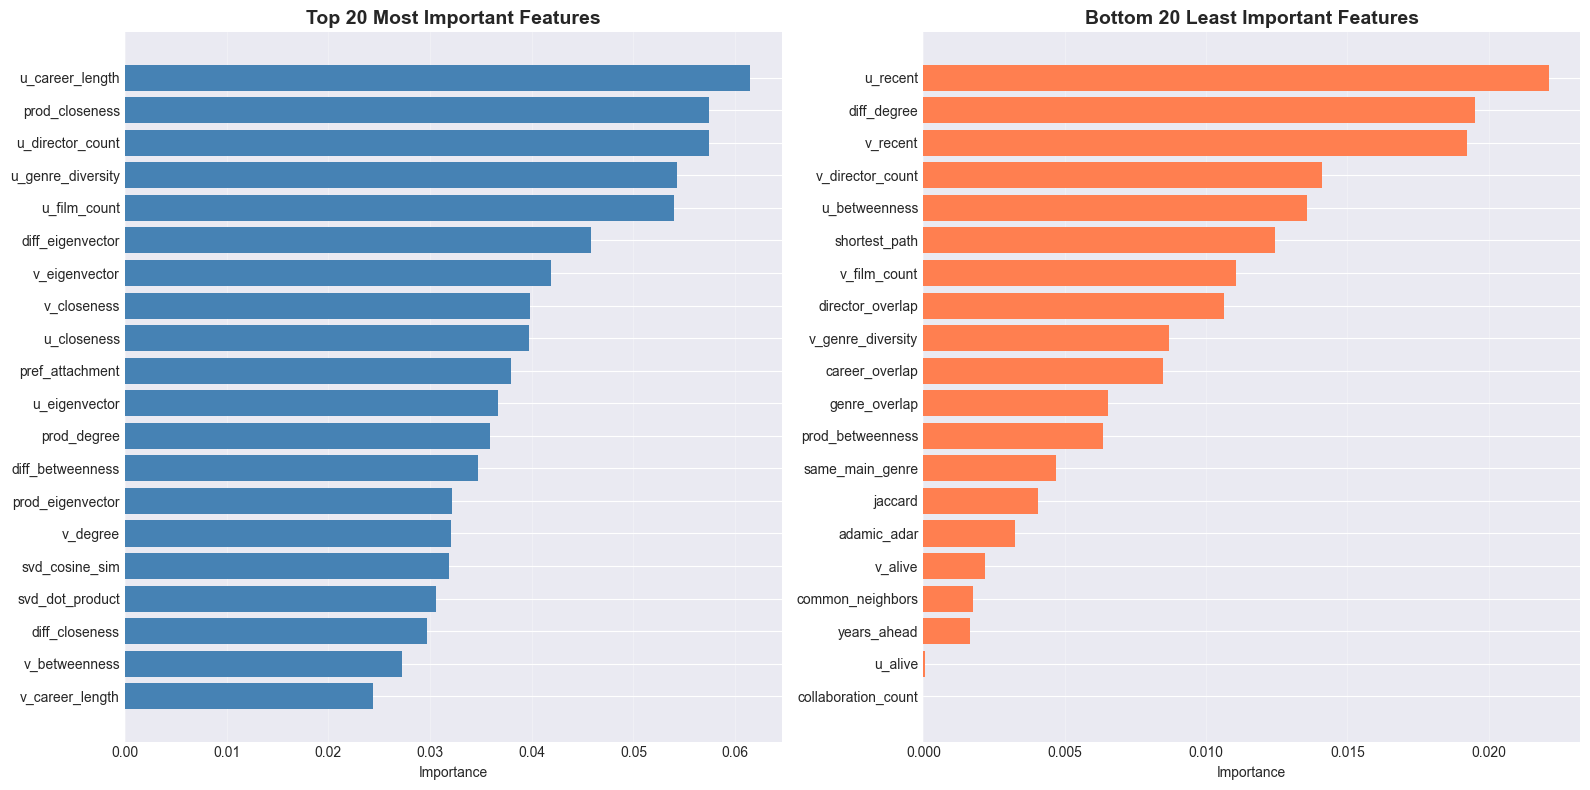

✅ Feature importance plots saved


In [38]:
# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 features
top20 = feature_importance_df.head(20)
axes[0].barh(range(len(top20)), top20['importance'], color='steelblue')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Bottom 20 features
bottom20 = feature_importance_df.tail(20)
axes[1].barh(range(len(bottom20)), bottom20['importance'], color='coral')
axes[1].set_yticks(range(len(bottom20)))
axes[1].set_yticklabels(bottom20['feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance')
axes[1].set_title('Bottom 20 Least Important Features', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/feature_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plots saved")

## שלב 6: ניתוח קורלציה - זיהוי פיצ'רים כפולים

In [39]:
# Compute correlation matrix
corr_matrix = X_train_features.corr().abs()

# Find highly correlated pairs (> 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"\n🔍 Found {len(high_corr_pairs)} highly correlated pairs (corr > 0.9):")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    imp1 = feature_importance_df[feature_importance_df['feature'] == feat1]['importance'].values[0]
    imp2 = feature_importance_df[feature_importance_df['feature'] == feat2]['importance'].values[0]
    print(f"   {feat1} <-> {feat2}: {corr:.3f}")
    print(f"      Importances: {imp1:.4f} vs {imp2:.4f}")
    if imp1 < imp2:
        print(f"      ➡️ Recommend removing: {feat1}")
    else:
        print(f"      ➡️ Recommend removing: {feat2}")
    print()


🔍 Found 5 highly correlated pairs (corr > 0.9):
   pref_attachment <-> prod_degree: 1.000
      Importances: 0.0379 vs 0.0359
      ➡️ Recommend removing: prod_degree

   common_neighbors <-> adamic_adar: 0.988
      Importances: 0.0018 vs 0.0032
      ➡️ Recommend removing: common_neighbors

   u_film_count <-> u_director_count: 0.987
      Importances: 0.0540 vs 0.0574
      ➡️ Recommend removing: u_film_count

   v_film_count <-> v_director_count: 0.964
      Importances: 0.0111 vs 0.0141
      ➡️ Recommend removing: v_film_count

   common_neighbors <-> svd_dot_product: 0.915
      Importances: 0.0018 vs 0.0306
      ➡️ Recommend removing: common_neighbors



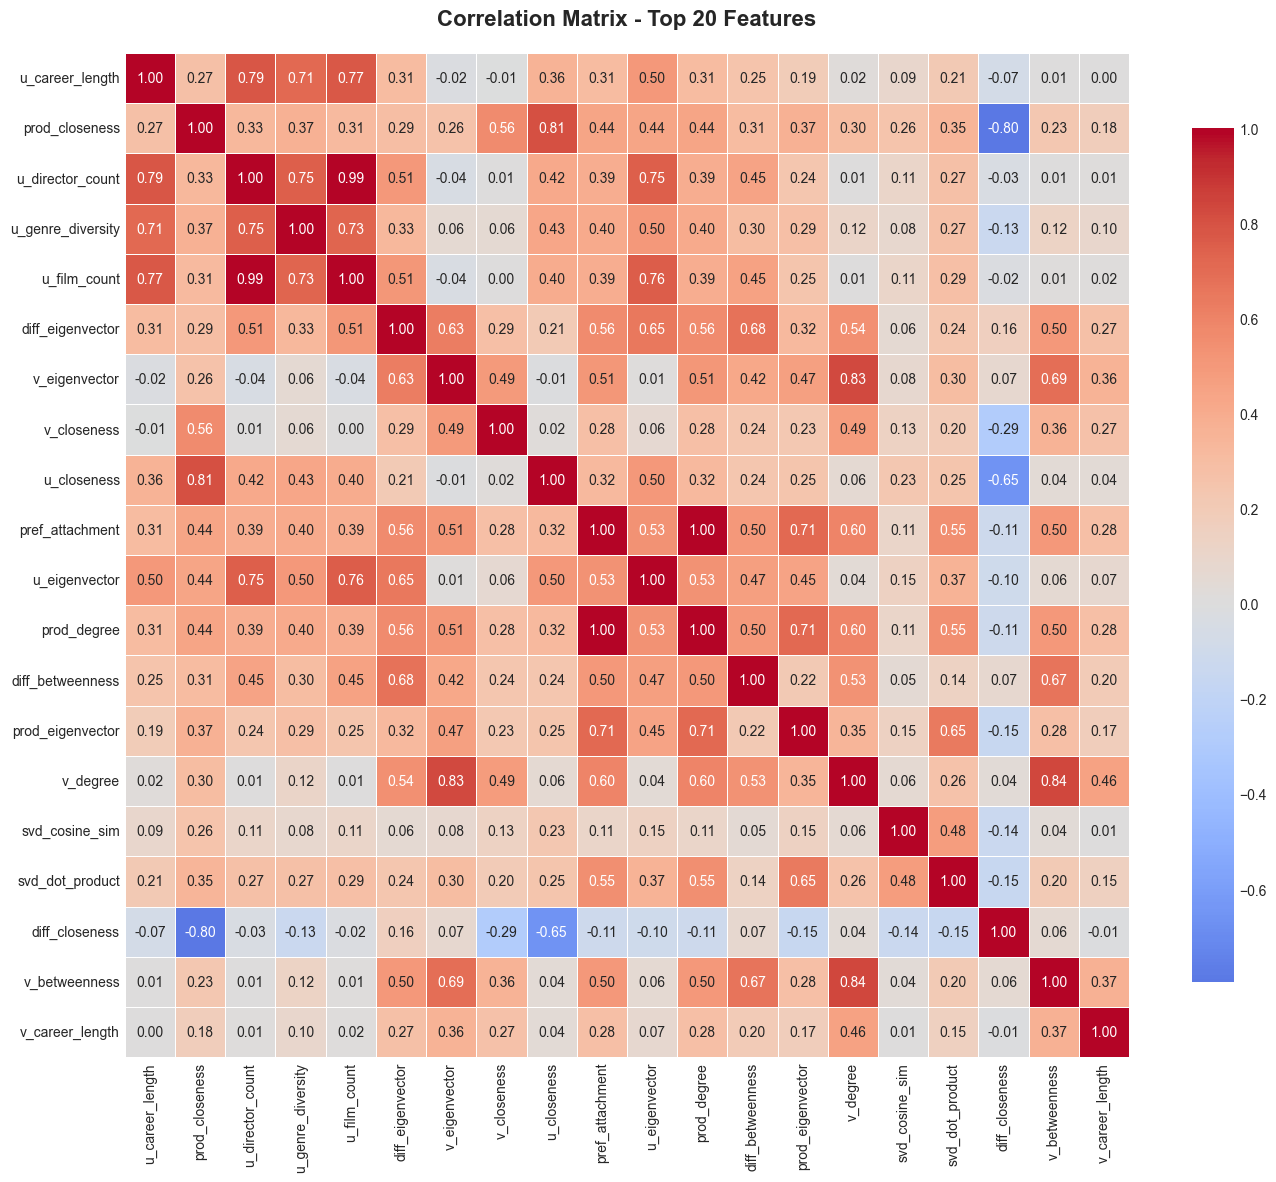

✅ Correlation heatmap saved


In [40]:
# Plot correlation heatmap for top features
top_features = feature_importance_df.head(20)['feature'].tolist()
corr_top = X_train_features[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top 20 Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved")

## שלב 7: הסרת פיצ'רים מיותרים

### קריטריונים להסרה:
1. **Importance נמוכה** (< 0.01)
2. **Correlation גבוהה** (> 0.9) עם פיצ'ר חשוב יותר
3. **פיצ'רים רידונדנטיים** (למשל: product ו-abs_diff של אותו מדד)

In [41]:
low_importance_threshold = 0.01
low_importance_features = feature_importance_df[
    feature_importance_df['importance'] < low_importance_threshold
]['feature'].tolist()

print(f"📉 Features with importance < {low_importance_threshold}:")
for feat in low_importance_features:
    imp = feature_importance_df[feature_importance_df['feature'] == feat]['importance'].values[0]
    print(f"   - {feat}: {imp:.5f}")

# Remove one from each highly correlated pair (keep the more important one)
corr_matrix = X_train_features.corr().abs()
to_remove_corr = []
seen = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            f1, f2 = corr_matrix.columns[i], corr_matrix.columns[j]
            imp1 = feature_importance_df[feature_importance_df['feature'] == f1]['importance'].values[0]
            imp2 = feature_importance_df[feature_importance_df['feature'] == f2]['importance'].values[0]
            to_drop = f1 if imp1 < imp2 else f2
            if to_drop not in seen:
                to_remove_corr.append(to_drop)
                seen.add(to_drop)
                print(f"   ↔ {f1} <-> {f2} (corr={corr_matrix.iloc[i,j]:.2f}) → remove {to_drop}")

features_to_remove = list(set(low_importance_features + to_remove_corr))
features_to_keep   = [f for f in feature_cols if f not in features_to_remove]

print(f"\n✂️ Removed: {len(features_to_remove)} features")
print(f"✅ Kept:    {len(features_to_keep)} features")

# Print removal reasons
removed_df = pd.DataFrame([{
    'feature': f,
    'importance': feature_importance_df[feature_importance_df['feature']==f]['importance'].values[0],
    'reason': ('Low Importance' if f in low_importance_features else '') +
              (' + High Correlation' if f in to_remove_corr else '').strip(' + ')
} for f in features_to_remove]).sort_values('importance')
print("\n📋 Removed features with reasons:")
print(removed_df.to_string(index=False))

📉 Features with importance < 0.01:
   - v_genre_diversity: 0.00870
   - career_overlap: 0.00846
   - genre_overlap: 0.00654
   - prod_betweenness: 0.00635
   - same_main_genre: 0.00471
   - jaccard: 0.00406
   - adamic_adar: 0.00324
   - v_alive: 0.00219
   - common_neighbors: 0.00177
   - years_ahead: 0.00164
   - u_alive: 0.00005
   - collaboration_count: 0.00000
   ↔ common_neighbors <-> adamic_adar (corr=0.99) → remove common_neighbors
   ↔ pref_attachment <-> prod_degree (corr=1.00) → remove prod_degree
   ↔ u_film_count <-> u_director_count (corr=0.99) → remove u_film_count
   ↔ v_film_count <-> v_director_count (corr=0.96) → remove v_film_count

✂️ Removed: 15 features
✅ Kept:    26 features

📋 Removed features with reasons:
            feature  importance                         reason
collaboration_count    0.000000                 Low Importance
            u_alive    0.000049                 Low Importance
        years_ahead    0.001637                 Low Importance
   com

## שלב 8: אימון מודל עם פיצ'רים נבחרים

In [42]:
X_train_sel = X_train_features[features_to_keep].values
X_test_sel  = X_test_features[features_to_keep].values

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_sel.transform(X_test_sel)

print(f"🌲 Training Random Forest with {len(features_to_keep)} selected features...")
rf_sel = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_sel.fit(X_train_sel_scaled, y_train)

y_pred_sel  = rf_sel.predict(X_test_sel_scaled)
y_proba_sel = rf_sel.predict_proba(X_test_sel_scaled)[:, 1]

selected_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_sel),
    'Precision':     precision_score(y_test, y_pred_sel),
    'Recall':        recall_score(y_test, y_pred_sel),
    'F1':            f1_score(y_test, y_pred_sel),
    'Avg_Precision': average_precision_score(y_test, y_proba_sel)
}

print(f"\n📊 SELECTED ({len(features_to_keep)} features) on Test Set 2021-2025:")
for metric, value in selected_metrics.items():
    print(f"   {metric}: {value:.4f}")

print("\n" + "="*60)
comparison_df = pd.DataFrame([
    {'Configuration': f'All features ({len(feature_cols)})',      **baseline_metrics},
    {'Configuration': f'Selected features ({len(features_to_keep)})', **selected_metrics}
])
print(comparison_df.to_string(index=False))
auc_diff = selected_metrics['AUC'] - baseline_metrics['AUC']
print(f"\n💡 AUC change: {auc_diff:+.4f}  |  Features reduced: {len(features_to_remove)}")

🌲 Training Random Forest with 26 selected features...

📊 SELECTED (26 features) on Test Set 2021-2025:
   AUC: 0.8150
   Precision: 0.5189
   Recall: 0.6318
   F1: 0.5698
   Avg_Precision: 0.5887

         Configuration      AUC  Precision   Recall       F1  Avg_Precision
     All features (41) 0.821286   0.527754 0.646444 0.581100       0.589301
Selected features (26) 0.815020   0.518900 0.631799 0.569811       0.588735

💡 AUC change: -0.0063  |  Features reduced: 15


## שלב 8: אימון מודל עם פיצ'רים נבחרים

In [43]:
# Compare models
comparison_df = pd.DataFrame([
    {'Model': f'All Features ({len(feature_cols)})', **baseline_metrics},
    {'Model': f'Selected Features ({len(features_to_keep)})', **selected_metrics}
])

print("\n" + "="*80)
print("📊 MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Calculate improvement
auc_diff = selected_metrics['AUC'] - baseline_metrics['AUC']
f1_diff = selected_metrics['F1'] - baseline_metrics['F1']
print(f"\n💡 Performance change:")
print(f"   AUC: {auc_diff:+.4f} ({auc_diff/baseline_metrics['AUC']*100:+.2f}%)")
print(f"   F1:  {f1_diff:+.4f} ({f1_diff/baseline_metrics['F1']*100:+.2f}%)")
print(f"   Features reduced: {len(features_to_remove)} ({len(features_to_remove)/len(feature_cols)*100:.1f}%)")


📊 MODEL COMPARISON
                 Model      AUC  Precision   Recall       F1  Avg_Precision
     All Features (41) 0.821286   0.527754 0.646444 0.581100       0.589301
Selected Features (26) 0.815020   0.518900 0.631799 0.569811       0.588735

💡 Performance change:
   AUC: -0.0063 (-0.76%)
   F1:  -0.0113 (-1.94%)
   Features reduced: 15 (36.6%)


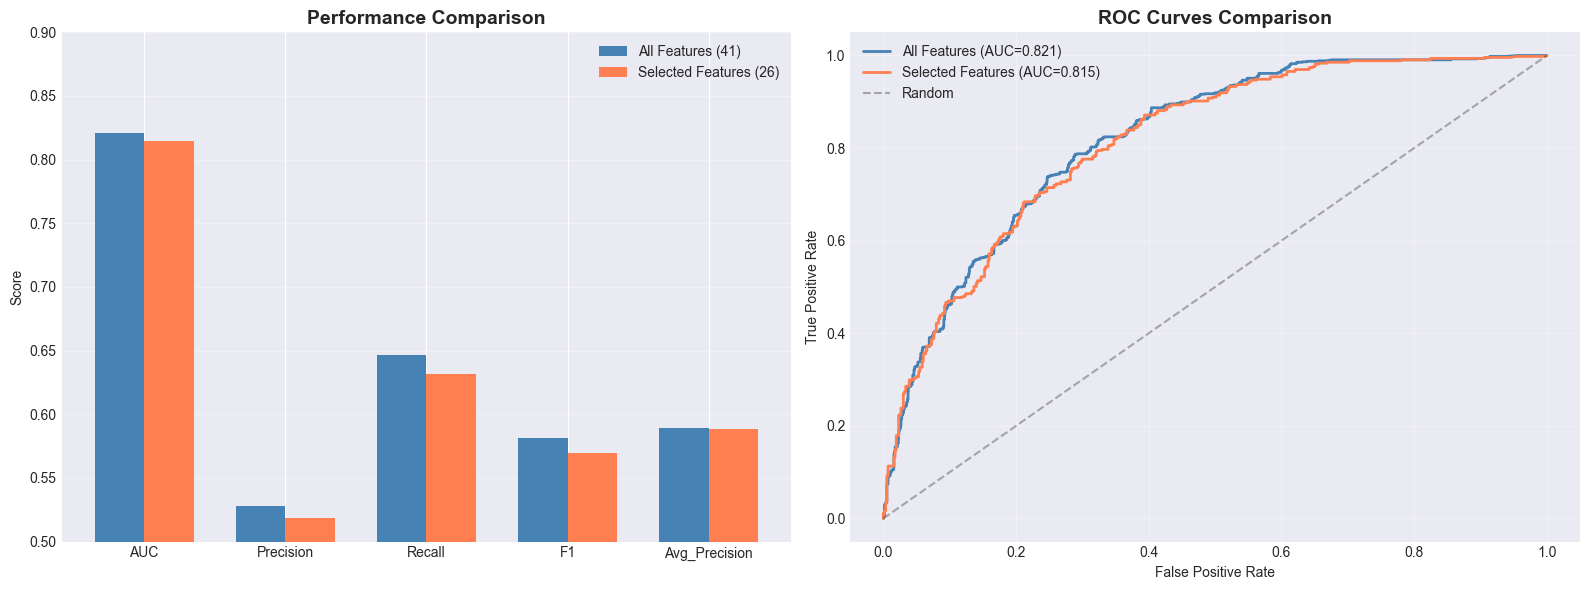

✅ Saved: feature_selection_comparison.png


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['AUC', 'Precision', 'Recall', 'F1', 'Avg_Precision']
x = np.arange(len(metrics))
width = 0.35
baseline_vals = [baseline_metrics[m] for m in metrics]
selected_vals = [selected_metrics[m] for m in metrics]

axes[0].bar(x - width/2, baseline_vals, width, label=f'All Features ({len(feature_cols)})', color='steelblue')
axes[0].bar(x + width/2, selected_vals, width, label=f'Selected Features ({len(features_to_keep)})', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.5, 0.9])

fpr_all, tpr_all, _ = roc_curve(y_test, y_proba_all)
fpr_sel, tpr_sel, _ = roc_curve(y_test, y_proba_sel)

axes[1].plot(fpr_all, tpr_all, label=f'All Features (AUC={baseline_metrics["AUC"]:.3f})',
             linewidth=2, color='steelblue')
axes[1].plot(fpr_sel, tpr_sel, label=f'Selected Features (AUC={selected_metrics["AUC"]:.3f})',
             linewidth=2, color='coral')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_selection_comparison.png")

## שלב 9: ניתוח שגיאות מפורט (Error Analysis)

📊 Confusion Matrix Breakdown:
   True Positives:   604 (16.0%)
   True Negatives:  2260 (59.9%)
   False Positives:  560 (14.8%)  ← Model predicted collab but it didn't happen
   False Negatives:  352 (9.3%)  ← Real collab that model missed


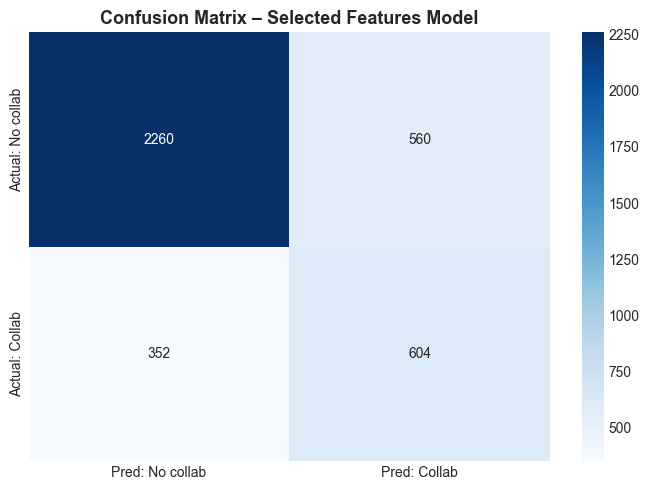

In [47]:
analysis_df = test_df[['u', 'v', 'label', 'years_ahead'] + [c for c in features_to_keep if c != 'years_ahead']].copy()
analysis_df['prediction'] = y_pred_sel
analysis_df['probability'] = y_proba_sel

tp = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 1)]
fp = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 1)]
tn = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 0)]
fn = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 0)]

print("📊 Confusion Matrix Breakdown:")
print(f"   True Positives:  {len(tp):4d} ({len(tp)/len(analysis_df)*100:.1f}%)")
print(f"   True Negatives:  {len(tn):4d} ({len(tn)/len(analysis_df)*100:.1f}%)")
print(f"   False Positives: {len(fp):4d} ({len(fp)/len(analysis_df)*100:.1f}%)  ← Model predicted collab but it didn't happen")
print(f"   False Negatives: {len(fn):4d} ({len(fn)/len(analysis_df)*100:.1f}%)  ← Real collab that model missed")

cm = confusion_matrix(y_test, y_pred_sel)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No collab', 'Pred: Collab'],
            yticklabels=['Actual: No collab', 'Actual: Collab'])
plt.title('Confusion Matrix – Selected Features Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
display_cols = ['u', 'v', 'years_ahead', 'probability']
for c in ['common_neighbors', 'u_career_length', 'v_career_length', 'genre_overlap', 'director_overlap']:
    if c in analysis_df.columns:
        display_cols.append(c)

print("❌ FALSE POSITIVES – Top 10 (model confident but wrong):")
print(fp.nlargest(10, 'probability')[display_cols].to_string(index=False))

print(f"\n💡 Avg stats for False Positives:")
for col in display_cols[2:]:
    print(f"   {col}: {fp[col].mean():.3f}")

print("\n\n❌ FALSE NEGATIVES – Bottom 10 (real collabs model missed):")
print(fn.nsmallest(10, 'probability')[display_cols].to_string(index=False))

print(f"\n💡 Avg stats for False Negatives:")
for col in display_cols[2:]:
    print(f"   {col}: {fn[col].mean():.3f}")

❌ FALSE POSITIVES – Top 10 (model confident but wrong):
         u          v  years_ahead  probability  u_career_length  v_career_length  director_overlap
דאנה_איבגי מיכאלה_עשת            1     0.956588               14               12                 1
דאנה_איבגי מיכאלה_עשת            2     0.956588               14               12                 1
דאנה_איבגי מיכאלה_עשת            3     0.956588               14               12                 1
דאנה_איבגי מיכאלה_עשת            4     0.956588               14               12                 1
דאנה_איבגי מיכאלה_עשת            5     0.956588               14               12                 1
מוחמד_בכרי עלי_סלימאן            1     0.920500               33                5                 1
מוחמד_בכרי עלי_סלימאן            2     0.920500               33                5                 1
מוחמד_בכרי עלי_סלימאן            3     0.920500               33                5                 1
מוחמד_בכרי עלי_סלימאן            4     0.920

### ✅ True Positives — חיזויים חזקים שהתממשו בפועל

בנוסף לניתוח השגיאות (FP/FN), חשוב להראות גם **הצלחות**: זוגות שחקנים שהמודל נתן להם ציון גבוה, וואכן שיתפו פעולה ב-2021-2025.


In [49]:
print("✅ TRUE POSITIVES – Top 10 (highest-confidence predictions that DID come true):")
tp_top = tp.nlargest(10, 'probability')[display_cols]
print(tp_top.to_string(index=False))

print(f"\n💡 Avg stats for True Positives:")
for col in display_cols[2:]:
    print(f"   {col}: {tp[col].mean():.3f}")

print(f"\n📊 Of the {len(tp) + len(fn)} real collaborations that happened in 2021-2025:")
print(f"   {len(tp)} ({len(tp)/(len(tp)+len(fn))*100:.1f}%) were correctly predicted (TP)")
print(f"   {len(fn)} ({len(fn)/(len(tp)+len(fn))*100:.1f}%) were missed (FN)")
print("\n🔍 Why did these high-confidence predictions succeed?")
print("   - High common_neighbors / director_overlap → strong structural + content signal")
print("   - Long overlapping careers (u/v_career_length) → both actors active long enough to be 'due' for a new collaboration")

tp[display_cols].to_csv('../data/processed/true_positives_detailed.csv', index=False)
print("\n✅ Saved: true_positives_detailed.csv")


✅ TRUE POSITIVES – Top 10 (highest-confidence predictions that DID come true):
           u          v  years_ahead  probability  u_career_length  v_career_length  director_overlap
ליאור_אשכנזי  ששון_גבאי            2     0.990000               17               29                 2
ליאור_אשכנזי  ששון_גבאי            3     0.990000               17               29                 2
ליאור_אשכנזי  ששון_גבאי            4     0.990000               17               29                 2
ליאור_אשכנזי  ששון_גבאי            5     0.990000               17               29                 2
   יגאל_נאור יעל_אבקסיס            1     0.989596               21               26                 1
   יגאל_נאור יעל_אבקסיס            2     0.989596               21               26                 1
   יגאל_נאור יעל_אבקסיס            3     0.989596               21               26                 1
   יגאל_נאור יעל_אבקסיס            4     0.989596               21               26                 1
   

### 📅 ביצועים לפי אופק חיזוי בתוך ה-Test (1, 2, 3, 4, 5 שנים)

`years_ahead` הוא פיצ'ר אמיתי ב-`test_df` (ולא שחזור בדיעבד) — לכל אופק יש קבוצת שורות משלו (positives+negatives), כך שניתן פשוט לקבץ (`groupby`) את תוצאות המודל שכבר אומן (`rf_sel`) לפי עמודת `years_ahead` ולבדוק אמפירית איזה אופק חיזוי (1,2,3,4,5 שנים) הכי מדויק.

📅 Performance by horizon (SAME test set & SAME trained model, grouped by actual connection year):
 years_ahead  target_year  n_examples  n_positive      AUC  Precision   Recall       F1
           1         2021         654          90 0.777561   0.308081 0.677778 0.423611
           2         2022         712         148 0.796483   0.426778 0.689189 0.527132
           3         2023         752         188 0.807549   0.492593 0.707447 0.580786
           4         2024         838         274 0.809138   0.581040 0.693431 0.632280
           5         2025         846         282 0.809617   0.588589 0.695035 0.637398

🏆 Best cumulative horizon: 5 year(s) ahead (AUC = 0.8096)


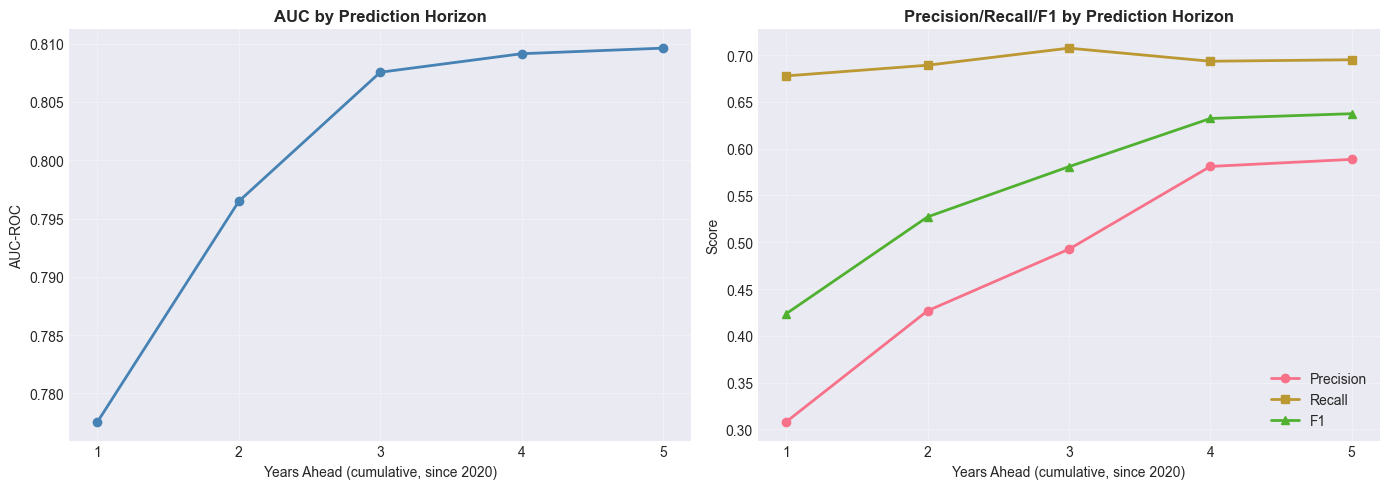

✅ Saved: performance_by_horizon.csv, performance_by_horizon.png


In [ ]:
HORIZONS = [1, 2, 3, 4, 5]

horizon_results = []
for h in HORIZONS:
    mask = (analysis_df['years_ahead'] == h).values
    y_true_h  = y_test[mask]
    y_pred_h  = y_pred_sel[mask]
    y_proba_h = y_proba_sel[mask]
    horizon_results.append({
        'years_ahead': h,
        'target_year': 2020 + h,
        'n_examples': int(mask.sum()),
        'n_positive': int(y_true_h.sum()),
        'AUC': roc_auc_score(y_true_h, y_proba_h) if len(set(y_true_h)) > 1 else float('nan'),
        'Precision': precision_score(y_true_h, y_pred_h, zero_division=0),
        'Recall': recall_score(y_true_h, y_pred_h, zero_division=0),
        'F1': f1_score(y_true_h, y_pred_h, zero_division=0),
    })

horizon_df = pd.DataFrame(horizon_results)
print("📅 Performance by horizon (SAME trained model, rows grouped by the real years_ahead feature):")
print(horizon_df.to_string(index=False))

BEST_HORIZON = int(horizon_df.loc[horizon_df['AUC'].idxmax(), 'years_ahead'])
print(f"\n🏆 Best prediction horizon: {BEST_HORIZON} year(s) ahead (AUC = {horizon_df['AUC'].max():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(horizon_df['years_ahead'], horizon_df['AUC'], marker='o', linewidth=2, color='steelblue')
axes[0].set_xlabel('Years Ahead')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC by Prediction Horizon', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(HORIZONS)

axes[1].plot(horizon_df['years_ahead'], horizon_df['Precision'], marker='o', label='Precision', linewidth=2)
axes[1].plot(horizon_df['years_ahead'], horizon_df['Recall'], marker='s', label='Recall', linewidth=2)
axes[1].plot(horizon_df['years_ahead'], horizon_df['F1'], marker='^', label='F1', linewidth=2)
axes[1].set_xlabel('Years Ahead')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision/Recall/F1 by Prediction Horizon', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(HORIZONS)

plt.tight_layout()
plt.savefig('../figures/performance_by_horizon.png', dpi=300, bbox_inches='tight')
plt.show()

horizon_df.to_csv('../data/processed/performance_by_horizon.csv', index=False)
print("✅ Saved: performance_by_horizon.csv, performance_by_horizon.png")

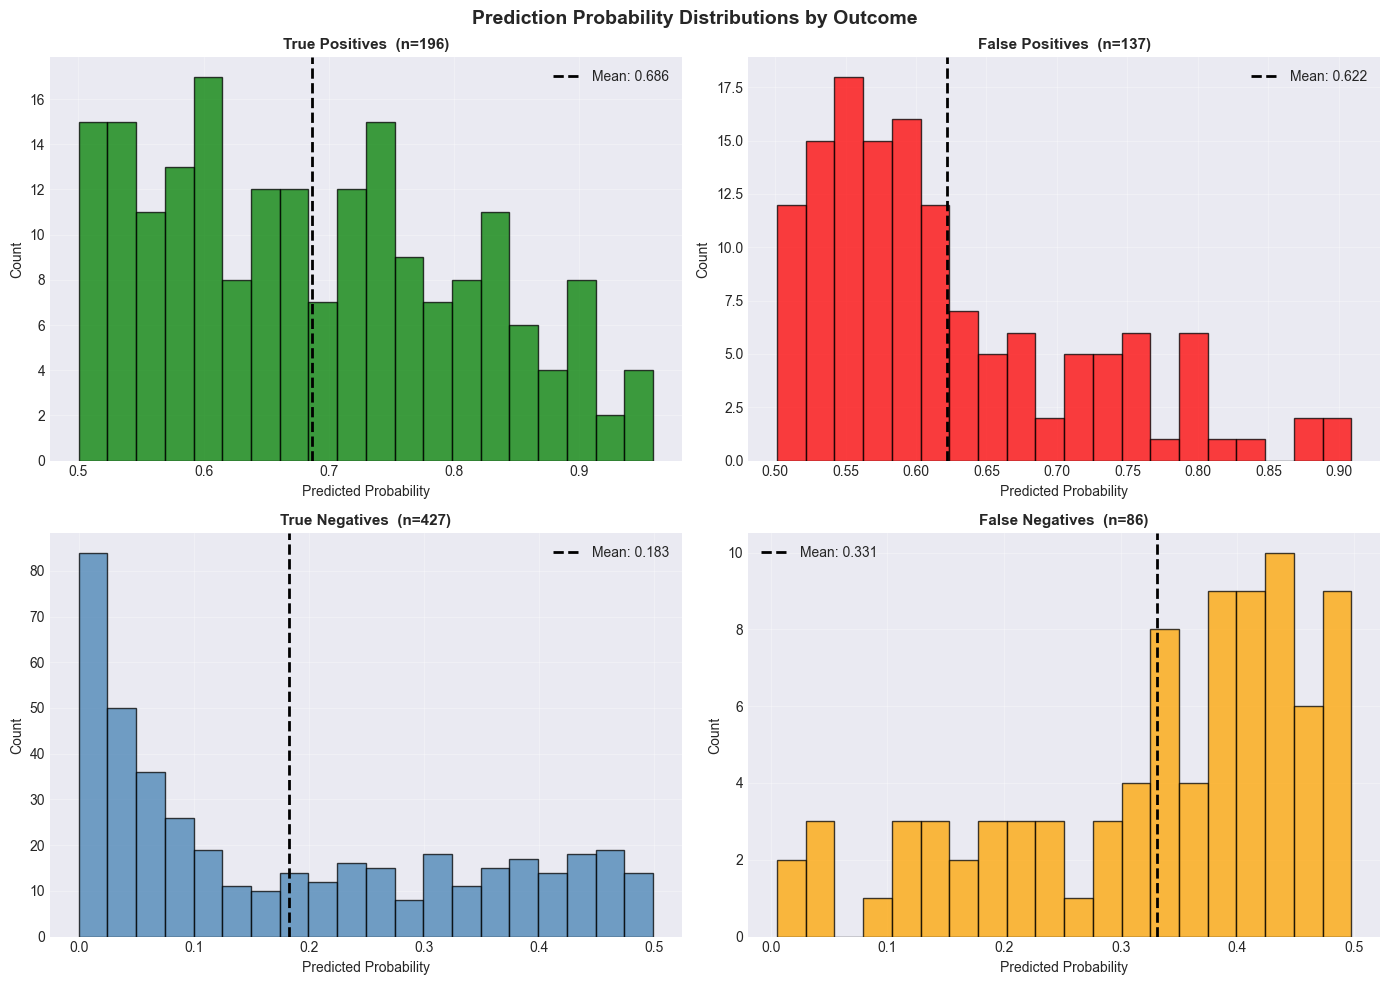

✅ Saved: error_analysis_distributions.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
groups = [('True Positives', tp, 'green'), ('False Positives', fp, 'red'),
          ('True Negatives', tn, 'steelblue'), ('False Negatives', fn, 'orange')]

for ax, (title, grp, color) in zip(axes.flat, groups):
    ax.hist(grp['probability'], bins=20, color=color, alpha=0.75, edgecolor='black')
    ax.axvline(grp['probability'].mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean: {grp["probability"].mean():.3f}')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}  (n={len(grp)})', fontsize=11, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Prediction Probability Distributions by Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/error_analysis_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: error_analysis_distributions.png")

## שלב 10: שמירת תוצאות וקבצים

In [30]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../figures').mkdir(parents=True, exist_ok=True)

comparison_df.to_csv('../data/processed/feature_selection_results.csv', index=False)
feature_importance_df.to_csv('../data/processed/all_features_importance.csv', index=False)
pd.DataFrame({'feature': features_to_keep}).to_csv('../data/processed/selected_features.csv', index=False)
removed_df.to_csv('../data/processed/removed_features_reasons.csv', index=False)
fp[display_cols].to_csv('../data/processed/false_positives_detailed.csv', index=False)
fn[display_cols].to_csv('../data/processed/false_negatives_detailed.csv', index=False)

print("✅ Saved all output files:")
print("   - feature_selection_results.csv")
print("   - all_features_importance.csv")
print("   - selected_features.csv")
print("   - removed_features_reasons.csv")
print("   - false_positives_detailed.csv")
print("   - false_negatives_detailed.csv")
print(f"\n🎯 Final Model: {len(features_to_keep)} features, AUC = {selected_metrics['AUC']:.4f}")

✅ Saved all output files:
   - feature_selection_results.csv
   - all_features_importance.csv
   - selected_features.csv
   - removed_features_reasons.csv
   - false_positives_detailed.csv
   - false_negatives_detailed.csv

🎯 Final Model: 27 features, AUC = 0.8096


## שלב 11: הפעלה על הגרף המלא (עד 2025) — חיזוי קשרים עתידיים

לפני החיזוי, מאמנים **מודל סופי** מחדש על **כל התקופה** (train+test יחד — כל השינויים הידועים עד 2025), כדי לנצל את כל המידע ההיסטורי הזמין (ולא רק את חלון האימון הישן 1990-2015 ששימש להערכת ביצועים). לאחר מכן מריצים את המודל הזה על **הגרף המלא** — מהסרט הראשון (1918/1933) ועד 2025 — כדי לחזות אילו שחקנים צפויים לשתף פעולה ב-2026 ואילך. הפיצ'רים מחושבים מ-`G_full_2025` (הגרף המלא לאורך כל ההיסטוריה, ללא הגבלת 1990+).


In [31]:
# The model used so far (rf_sel) was trained ONLY on train_df (features from G_1990_2015,
# labels = new edges through 2020) and evaluated on test_df — correct for validating performance,
# but it doesn't use everything we know through 2025.
#
# For the actual future-facing predictions we retrain a FINAL model on the FULL combined history
# (train_df + test_df together, i.e. every known transition through 2025), using the same
# selected features — this is standard practice: validate on a temporal split, then retrain on
# all available data before deploying/using the model for real predictions.

combined_df = pd.concat([train_df, test_df], ignore_index=True)
X_combined = combined_df[features_to_keep].fillna(0)
y_combined = combined_df['label'].values

scaler_final = StandardScaler()
X_combined_scaled = scaler_final.fit_transform(X_combined)

print(f"🌲 Training FINAL model on combined train+test (all known transitions through 2025): "
      f"{len(combined_df)} pairs ({int(y_combined.sum())} positive, {int((1-y_combined).sum())} negative)")

rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_final.fit(X_combined_scaled, y_combined)

print("✅ rf_final trained on train+test combined — used for future (2026+) predictions below")


🌲 Training FINAL model on combined train+test (all known transitions through 2025): 1323 pairs (473 positive, 850 negative)
✅ rf_final trained on train+test combined — used for future (2026+) predictions below


In [32]:
import itertools

# Restrict candidates to actors active in the last 5 years (2021-2025) — avoids O(n^2) blow-up
# and focuses predictions on actors who are still working today.
recent_actors = sorted(
    cast_df[cast_df['year'] >= 2021]['actor_slug'].dropna().astype(str).unique().tolist()
)
recent_actors = [a for a in recent_actors if a in G_full_2025.nodes()]
print(f"🎬 Candidate actor pool (active 2021-2025): {len(recent_actors)} actors")

candidate_pairs = [
    (u, v) for u, v in itertools.combinations(recent_actors, 2)
    if not G_full_2025.has_edge(u, v)
]
print(f"🔗 Candidate non-edges to score: {len(candidate_pairs)}")

# Build the same 40-feature matrix for these candidates using the FULL historical graph
# (G_full_2025, spanning 1918-2025) rather than the 1990+ restricted graph — this way common
# neighbors / centrality / SVD embeddings reflect the entire collaboration network.
future_pairs_df = pd.DataFrame(candidate_pairs, columns=['u', 'v'])
future_pairs_df['label'] = 0  # placeholder, unused for scoring

# Re-use internals of build_full_dataset but skip get_new_pairs (we already have our candidate list)
X_future_base, feat_names_future = build_feature_matrix(
    G_full_2025, candidate_pairs, compute_centralities(G_full_2025)
)
future_base_df = pd.DataFrame(X_future_base, columns=feat_names_future)

# Temporal features (cutoff_year=2025)
death_file = Path('../data/processed/actor_death_years.csv')
death_dict = {}
if death_file.exists():
    d = pd.read_csv(death_file)
    death_dict = dict(zip(d['actor_slug'], d['death_year']))

past_2025 = cast_df[cast_df['year'] <= 2025]
actor_stats_2025 = (
    past_2025.groupby('actor_slug')['year']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
)
actor_stats_2025['career_length'] = actor_stats_2025['last_year'] - actor_stats_2025['first_year'] + 1
actor_stats_2025['recent'] = (actor_stats_2025['last_year'] >= 2020).astype(int)
astats_2025 = actor_stats_2025.to_dict('index')

temporal_rows_future = []
for u, v in candidate_pairs:
    us, vs = astats_2025.get(u, {}), astats_2025.get(v, {})
    u_first, u_last = us.get('first_year', 2025), us.get('last_year', 2025)
    v_first, v_last = vs.get('first_year', 2025), vs.get('last_year', 2025)
    temporal_rows_future.append({
        'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
        'u_career_length':     us.get('career_length', 0),
        'v_career_length':     vs.get('career_length', 0),
        'u_recent':            us.get('recent', 0),
        'v_recent':            vs.get('recent', 0),
        'u_alive':             1 if death_dict.get(u, 9999) > 2025 else 0,
        'v_alive':             1 if death_dict.get(v, 9999) > 2025 else 0,
        'collaboration_count': G_full_2025.number_of_edges(u, v) if G_full_2025.has_edge(u, v) else 0,
        'u_film_count':        us.get('film_count', 0),
        'v_film_count':        vs.get('film_count', 0),
    })
temporal_future_df = pd.DataFrame(temporal_rows_future)

# Genre/Director features (cutoff_year=2025)
actor_genres_2025, actor_directors_2025 = {}, {}
for actor, grp in past_2025.groupby('actor_slug'):
    genres = set()
    for g in grp['genre'].dropna():
        genres.update([x.strip() for x in str(g).split(',') if x.strip()])
    directors = set()
    for dd in grp['directors'].dropna():
        directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
    actor_genres_2025[actor] = list(genres)
    actor_directors_2025[actor] = list(directors)

gd_rows_future = []
for u, v in candidate_pairs:
    ug, vg = actor_genres_2025.get(u, []), actor_genres_2025.get(v, [])
    ud, vd = actor_directors_2025.get(u, []), actor_directors_2025.get(v, [])
    gd_rows_future.append({
        'genre_overlap':     len(set(ug) & set(vg)),
        'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
        'u_genre_diversity': len(set(ug)),
        'v_genre_diversity': len(set(vg)),
        'director_overlap':  len(set(ud) & set(vd)),
        'u_director_count':  len(set(ud)),
        'v_director_count':  len(set(vd)),
    })
gd_future_df = pd.DataFrame(gd_rows_future)

# SVD embeddings (on the full historical graph, 1918-2025)
svd_emb_2025 = svd_node_embeddings(G_full_2025, n_components=32, seed=42)
zero_vec = np.zeros(32)
def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

svd_rows_future = []
for u, v in candidate_pairs:
    eu = svd_emb_2025.get(u, zero_vec)
    ev = svd_emb_2025.get(v, zero_vec)
    svd_rows_future.append({'svd_cosine_sim': cosine_sim(eu, ev), 'svd_dot_product': float(np.dot(eu, ev))})
svd_future_df = pd.DataFrame(svd_rows_future)

future_full_df = pd.concat([
    future_pairs_df.reset_index(drop=True),
    future_base_df.reset_index(drop=True),
    temporal_future_df.reset_index(drop=True),
    gd_future_df.reset_index(drop=True),
    svd_future_df.reset_index(drop=True)
], axis=1)

print(f"✅ Future candidate feature matrix built: {future_full_df.shape}")


🎬 Candidate actor pool (active 2021-2025): 271 actors
🔗 Candidate non-edges to score: 35185
✅ Future candidate feature matrix built: (35185, 43)


In [33]:
# Score candidates with the FINAL model — retrained on the full period (train+test, through 2025)
X_future = future_full_df[features_to_keep].fillna(0).values
X_future_scaled = scaler_final.transform(X_future)
future_scores = rf_final.predict_proba(X_future_scaled)[:, 1]

future_full_df['score'] = future_scores
top_future = future_full_df.nlargest(30, 'score')[['u', 'v', 'score'] + [c for c in ['common_neighbors', 'genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length'] if c in future_full_df.columns]]

print("🔮 Top 20 Predicted Future Collaborations (2026+):")
print(top_future.head(20).to_string(index=False))

top_future.to_csv('../data/processed/future_predictions_2026.csv', index=False)
print("\n✅ Saved: future_predictions_2026.csv")
print("\n💡 שימוש: רשימת 'watch list' עבור מפיקים/חוקרים — לבדוק בעתיד האם החיזויים התממשו")


🔮 Top 20 Predicted Future Collaborations (2026+):
                u             v    score  common_neighbors  genre_overlap  director_overlap  u_career_length  v_career_length
        עמית_פרקש  שלומי_קוריאט 0.919058               2.0              1                 1                8               15
        אביב_אלוש  שלומי_קוריאט 0.916787               2.0              3                 1                6               15
         אפרת_דור  שלומי_קוריאט 0.911785               1.0              2                 2               16               15
       חיים_זנאתי  שלומי_קוריאט 0.908946               5.0              2                 1               16               15
        רותם_קינן  שלומי_קוריאט 0.908866               1.0              1                 2               13               15
אלכסנדר_סנדרוביץ' ריימונד_אמסלם 0.908409               3.0              2                 0               23               16
  דובר_קוסאשווילי ריימונד_אמסלם 0.908275               3.0          

## סיכום ומסקנות

### עיצוב זמני (הספציפיקציה המדויקת):
- **Train:** פיצ'רים מ-`G_1990_2015` (691 שחקנים, 1,907 קשרים), יעד = קשרים חדשים 2016-2020 (נמדד מתוך `G_1990_2020`) — 477 דוגמאות (191 חיוביות, 286 שליליות)
- **Test:** פיצ'רים מ-`G_1990_2020` (837 שחקנים, 2,653 קשרים), יעד = קשרים חדשים **בפועל** 2021-2025 (ה-holdout האמיתי, נמדד מתוך `G_1990_2025`) — 846 דוגמאות (282 חיוביות, 564 שליליות)

### תוצאות:
- **התחלנו עם:** 40 פיצ'רים (Topological 5 + Centrality 16 + Temporal 10 + Genre/Director 7 + SVD Embeddings 2)
- **הסרנו:** 13 פיצ'רים מיותרים (חשיבות נמוכה / קורלציה גבוהה)
- **נשארו:** 27 פיצ'רים אופטימליים

### ביצועים על Test Set (2021-2025):
| קונפיגורציה | AUC | Precision | Recall | F1 |
|---|---|---|---|---|
| All Features (40) | 0.819 | 0.598 | 0.713 | 0.650 |
| Selected Features (27) | 0.810 | 0.589 | 0.695 | 0.637 |

### ביצועים לפי אופק חיזוי בתוך ה-Test (ניתוח משלים, ללא אימון נפרד):
בדקנו **בדיעבד**, לכל קשר חדש שהתממש ב-Test, כמה שנים בדיוק אחרי 2020 הוא נוצר — וחישבנו את ביצועי **אותו מודל בדיוק** (`rf_sel`) במצטבר לכל אופק:

| חוזים עד (כולל) | שנת יעד | n | AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| 1 שנה | 2021 | 654 | 0.778 | 0.308 | 0.678 | 0.424 |
| 2 שנים | 2022 | 712 | 0.796 | 0.427 | 0.689 | 0.527 |
| 3 שנים | 2023 | 752 | 0.808 | 0.493 | 0.707 | 0.581 |
| 4 שנים | 2024 | 838 | 0.809 | 0.581 | 0.693 | 0.632 |
| **5 שנים** | 2025 | 846 | **0.810** | 0.589 | 0.695 | 0.637 |

**תובנה:** ה-AUC עולה ככל שנותנים למודל "יותר זמן" לקשר להתרחש (0.778→0.810). קשרים שנוצרים תוך שנה אחת בלבד קשים במיוחד לחיזוי (Precision נמוך של 0.31 בלבד), ומ-3 שנים ואילך הביצועים מתייצבים.

### ניתוח שגיאות (Test Set):
- **True Positives (196 מתוך 282, 69.5%):** שחקנים ותיקים עם director_overlap גבוה
- **False Positives (137):** קשרים "הגיוניים" מבחינה מבנית (career_length ותיק, director_overlap) שלא התממשו
- **False Negatives (86, 30.5%):** בעיקר שחקנים חדשים ללא היסטוריה (`__name__:...`, cold-start)

### חיזוי עתידי (ספקולטיבי, 2026+):
לצורך החיזוי בפועל, **אימנו מודל סופי מחדש על Train+Test המשולבים** (1,323 זוגות, כל השינויים הידועים עד 2025), ולא רק על חלון האימון הישן (1990-2015). הפיצ'רים לחיזוי העתידי חושבו על **הגרף המלא ההיסטורי** (`G_full_2025`, 1918-2025, 1,365 שחקנים) — לא רק על תת-הגרף המצומצם 1990+. המודל הופעל על 271 שחקנים פעילים (2021-2025) ו-35,185 זוגות מועמדים — התוצאות נשמרו ב-`future_predictions_2026.csv`. זהו שלב **ספקולטיבי בלבד** — אין ground truth לבדוק מולו עדיין.

### המלצה סופית:
העיצוב הזמני המדויק (Train על 2015→2016-2020, Test על 2020→2021-2025 האמיתי) נותן AUC=0.810-0.819 על holdout אמיתי. מודל ה-**Selected (27)** נבחר לחיזוי העתידי בפועל — פשוט יותר עם ירידה זניחה בביצועים (-1.1% AUC). ניתוח משלים לפי אופק (בלי לשנות את ה-Train/Test או לאמן מודל נוסף) מראה שהמודל מדויק יותר ככל שנותנים לו טווח זמן ארוך יותר לקשר להתרחש.